In [2]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np

Kode di atas digunakan untuk mengimpor library yang dibutuhkan selama proses pengolahan citra. cv2 adalah library OpenCV yang digunakan untuk membaca dan memproses citra. matplotlib.pyplot diimpor sebagai plt dan digunakan untuk menampilkan citra secara visual. numpy diimpor sebagai np dan digunakan untuk operasi matematis pada array piksel citra.

Kode di bawah digunakan untuk membaca gambar backup.jpg yang merupakan citra CCTV berkualitas rendah. Gambar dibaca langsung dalam mode grayscale menggunakan parameter cv2.IMREAD_GRAYSCALE, sehingga citra yang tersimpan di variabel cctv sudah berupa citra abu-abu satu kanal tanpa perlu konversi tambahan. Citra kemudian ditampilkan menggunakan plt.imshow dengan parameter cmap='gray'. plt.axis("off") digunakan untuk menyembunyikan sumbu koordinat agar tampilan lebih bersih.

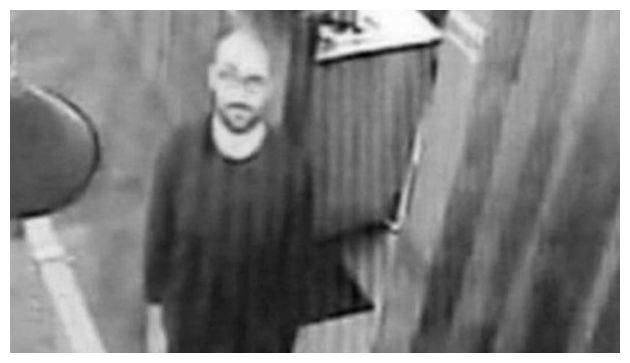

In [3]:
path_backup = 'backup.jpg'

cctv = cv2.imread(path_backup, cv2.IMREAD_GRAYSCALE)

plt.imshow(cctv, cmap='gray')
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad = size // 2
    padded = np.pad(img, pad, mode='constant')
    h, w = img.shape[:2]
    hasil = np.zeros_like(img).astype(np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            hasil[i, j] = np.sum(region * kernel)
    return hasil

def gaussian_blur_manual(img, sigma=1.0):
    size = int(2 * np.ceil(2 * sigma) + 1)
    x, y = np.mgrid[-size//2 + 1:size//2 + 1, -size//2 + 1:size//2 + 1]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return convolution(img, kernel).astype(np.uint8)

def sobel_edge_detection(img):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    Ix = convolution(img, Kx)
    Iy = convolution(img, Ky)
    magnitude = np.sqrt(Ix**2 + Iy**2)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

def threshold_inv_manual(img, nilai=127):
    h, w = img.shape[:2]
    hasil = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = 255 if int(img[i, j]) < nilai else 0
    return hasil

def smoothing(img):
    kernel = np.array([[1/10, 1/10, 1/10], [1/10, 1/5, 1/10], [1/10, 1/10, 1/10]])
    hasil = convolution(img, kernel)
    return np.clip(hasil, 0, 255).astype(np.uint8)

def sharpening(img):
    kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    hasil = convolution(img, kernel)
    return np.clip(hasil, 0, 255).astype(np.uint8)

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.median(region)
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        count[val] = count.get(val, 0) + 1
                    mode_val = max(count, key=count.get)
                    canvas[i, j] = mode_val
    return canvas

def tambah_citra(img1, img2):
    h, w = img1.shape[:2]
    hasil = np.zeros_like(img1)
    if len(img1.shape) == 3:
        for i in range(h):
            for j in range(w):
                for c in range(img1.shape[2]):
                    hasil[i, j, c] = np.clip(int(img1[i, j, c]) + int(img2[i, j, c]), 0, 255)
    else:
        for i in range(h):
            for j in range(w):
                hasil[i, j] = np.clip(int(img1[i, j]) + int(img2[i, j]), 0, 255)
    return hasil

Cell di atas mendefinisikan semua fungsi utama yang akan digunakan sepanjang proses pengolahan citra, mulai dari konvolusi manual sebagai dasar operasi filtering, gaussian blur, smoothing, dan sharpening untuk perbaikan kualitas citra, hingga fungsi filtering statistik (mean, median, modus), deteksi tepi dengan operator Sobel, thresholding terbalik, dan penjumlahan dua citra. Semua fungsi dibangun secara manual tanpa memanggil fungsi siap pakai dari OpenCV, sehingga proses perhitungan piksel dilakukan langsung menggunakan operasi array NumPy.

Kode di atas digunakan untuk menerapkan tiga jenis filtering pada citra CCTV dan membandingkan hasilnya secara berdampingan. Pertama, cctv.copy() digunakan agar citra asli tidak ikut termodifikasi selama proses. Kemudian fungsi filter dipanggil tiga kali dengan mode yang berbeda, mean, median, dan modus, masing-masing dengan ukuran kernel 3×3. Hasil ketiga filter ditampilkan dalam satu baris menggunakan plt.subplots(1, 3) agar mudah dibandingkan secara visual.

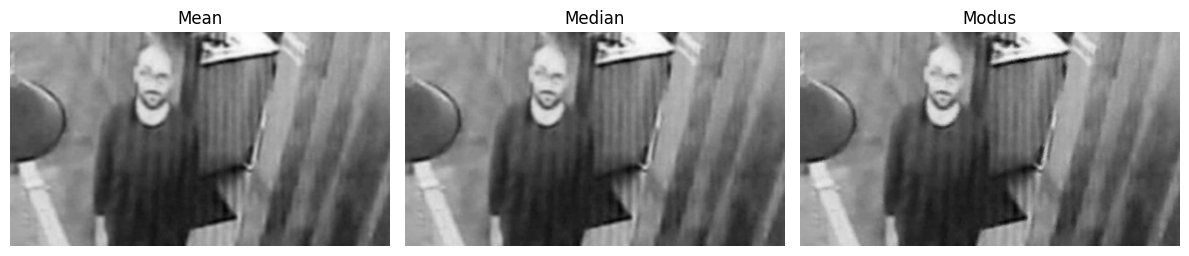

In [5]:
cctv_copy = cctv.copy()

cctv_mean = filter(cctv_copy, 3, mode="mean")
cctv_median = filter(cctv_copy, 3, mode="median")
cctv_modus = filter(cctv_copy, 3, mode="modus")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
ax1.imshow(cctv_mean, cmap="gray"); ax1.set_title("Mean")
ax2.imshow(cctv_median, cmap="gray"); ax2.set_title("Median")
ax3.imshow(cctv_modus, cmap="gray"); ax3.set_title("Modus")

ax1.axis("off"); ax2.axis("off"); ax3.axis("off")
plt.tight_layout()
plt.show()

Kode di bawahigunakan untuk menerapkan dan membandingkan tiga pendekatan perbaikan kualitas citra: smoothing saja, sharpening saja, dan kombinasi keduanya. cctv_smooth dihasilkan dengan memanggil fungsi smoothing langsung pada citra asli. cctv_sharp dihasilkan dengan fungsi sharpening. Untuk kombinasi, cctv_combine dihasilkan dengan menerapkan smoothing terlebih dahulu pada citra, kemudian hasilnya diproses lagi dengan sharpening.Pendekatan ini bertujuan untuk mengurangi noise terlebih dahulu sebelum mempertajam tepi objek. Ketiga hasil ditampilkan secara berdampingan untuk memudahkan perbandingan visual.

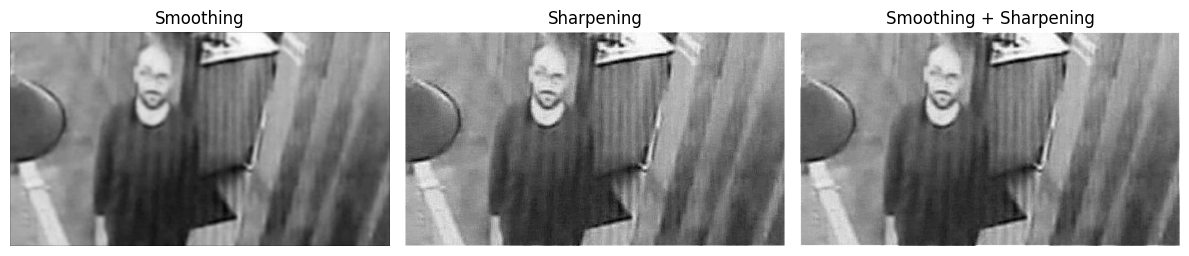

In [6]:
cctv_smooth = smoothing(cctv_copy)
cctv_sharp = sharpening(cctv_copy)
cctv_combine = sharpening(smoothing(cctv_copy))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
ax1.imshow(cctv_smooth, cmap="gray"); ax1.set_title("Smoothing")
ax2.imshow(cctv_sharp, cmap="gray"); ax2.set_title("Sharpening")
ax3.imshow(cctv_combine, cmap="gray"); ax3.set_title("Smoothing + Sharpening")

ax1.axis("off"); ax2.axis("off"); ax3.axis("off")
plt.tight_layout()
plt.show()

In [7]:
def normalize(img):
    img = np.abs(img)
    if np.max(img) > 0:
        img = (img / np.max(img)) * 255
    return img.astype(np.uint8)

def sobel(img):
    sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    gx = convolution(img, sx)
    gy = convolution(img, sy)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

def prewitt(img):
    px = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    py = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    gx = convolution(img, px)
    gy = convolution(img, py)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

def roberts(img):
    rx = np.array([[1, 0], [0, -1]])
    ry = np.array([[0, 1], [-1, 0]])
    gx = convolution(img, rx)
    gy = convolution(img, ry)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

def edge_detection(img, kernel_x, kernel_y):
    gx = convolution(img, kernel_x)
    gy = convolution(img, kernel_y)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

Cell ini mendefinisikan fungsi-fungsi yang digunakan untuk proses deteksi tepi, yaitu normalize untuk mengembalikan nilai piksel hasil konvolusi ke rentang 0–255, serta tiga operator deteksi tepi, Sobel, Prewitt, dan Roberts yang masing-masing bekerja dengan menghitung gradien horizontal dan vertikal secara terpisah lalu menjumlahkan hasilnya secara absolut. Selain itu, terdapat fungsi edge_detection sebagai versi generik yang menerima kernel kustom dari luar fungsi.

Kode di atas digunakan untuk menerapkan ketiga operator deteksi tepi (Prewitt, Sobel, Roberts) pada citra CCTV dan membandingkan hasilnya, termasuk hasil kombinasi antar operator. Setiap operator diterapkan secara terpisah terlebih dahulu menggunakan fungsi masing-masing. Kemudian kombinasi dua operator dilakukan dengan menjumlahkan hasil deteksi tepi keduanya menggunakan fungsi tambah_citra, lalu dinormalisasi kembali ke rentang 0–255 menggunakan normalize. Hasilnya, terdapat enam gambar yang ditampilkan dalam grid 2×3: Prewitt, Sobel, Roberts di baris pertama, serta Prewitt+Sobel, Prewitt+Roberts, Sobel+Roberts di baris kedua.

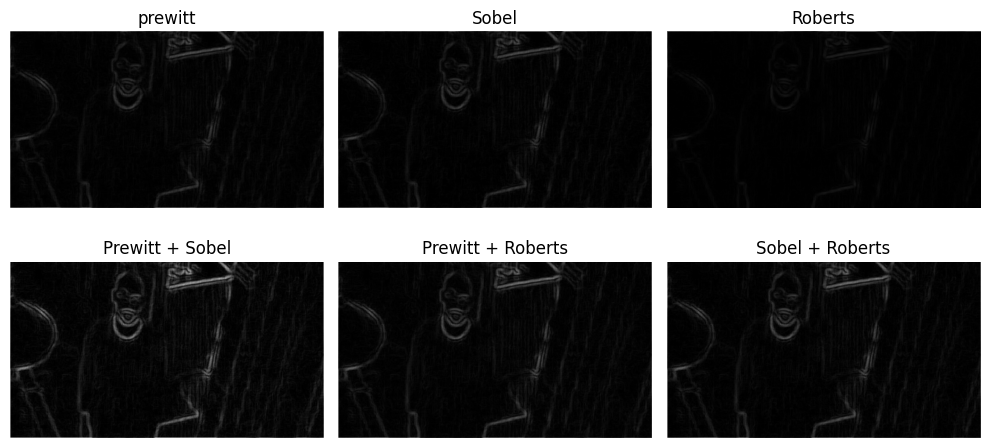

In [8]:
cctv_prewitt = prewitt(cctv_copy)
cctv_sobel = sobel(cctv_copy)
cctv_roberts = roberts(cctv_copy)
ps = tambah_citra(cctv_prewitt, cctv_sobel)
pr = tambah_citra(cctv_prewitt, cctv_roberts)
sr = tambah_citra(cctv_sobel, cctv_roberts)
prewitt_sobel = normalize(ps)
prewitt_roberts = normalize(pr)
sobel_roberts = normalize(sr)

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(10, 5))
ax1.imshow(cctv_prewitt, cmap="gray"); ax1.set_title("prewitt")
ax2.imshow(cctv_sobel, cmap="gray"); ax2.set_title("Sobel")
ax3.imshow(cctv_roberts, cmap="gray"); ax3.set_title("Roberts")
ax4.imshow(prewitt_sobel, cmap="gray"); ax4.set_title("Prewitt + Sobel")
ax5.imshow(prewitt_roberts, cmap="gray"); ax5.set_title("Prewitt + Roberts")
ax6.imshow(sobel_roberts, cmap="gray"); ax6.set_title("Sobel + Roberts")

ax1.axis("off")
ax2.axis("off")
ax3.axis("off")
ax4.axis("off")
ax5.axis("off")
ax6.axis("off")

plt.tight_layout()
plt.show()

Kode di bawah melanjutkan proses kombinasi operator dengan menggabungkan ketiga operator sekaligus. prewitt_sobel yang sudah merupakan hasil gabungan Prewitt dan Sobel dijumlahkan lagi dengan cctv_roberts menggunakan fungsi tambah_citra. Hasil penjumlahan kemudian dinormalisasi kembali menggunakan normalize dan disimpan di variabel prewitt_sobel_roberts. Hasilnya ditampilkan sebagai satu gambar tunggal dengan judul "Prewitt + Sobel + Roberts".

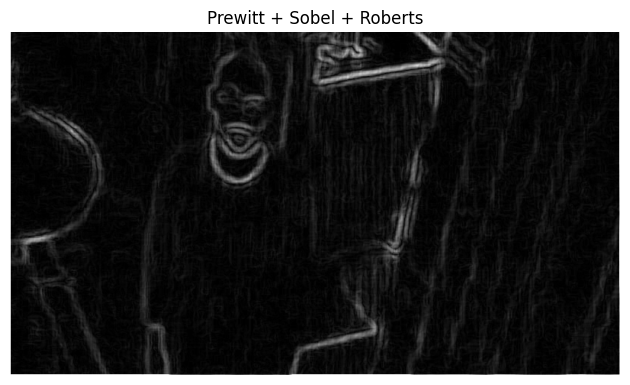

In [9]:
psr = tambah_citra(prewitt_sobel, cctv_roberts)
prewitt_sobel_roberts = normalize(psr)

plt.imshow(prewitt_sobel_roberts, cmap="gray")
plt.title("Prewitt + Sobel + Roberts")
plt.axis("off")
plt.tight_layout()
plt.show()

Fungsi ini diterapkan pada hasil deteksi tepi Prewitt (cctv_prewitt) dengan nilai threshold 10, 20, 30, 40, 50, dan 60. Keenam hasil ditampilkan dalam grid 2×3 untuk memudahkan perbandingan pengaruh nilai threshold terhadap jumlah tepi yang terdeteksi semakin tinggi nilai threshold, semakin sedikit tepi yang lolos dan tampil.

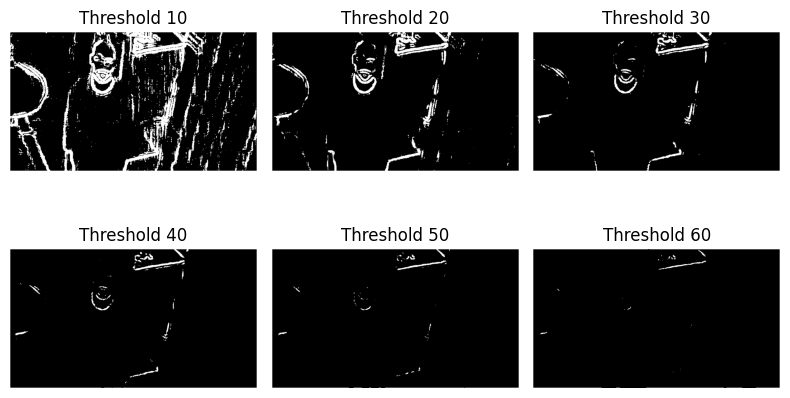

In [10]:
def threshold(img, nilai=127, maks=255):
    h, w = img.shape[:2]
    hasil = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = maks if int(img[i, j]) >= nilai else 0
    return hasil

cctv_ten = threshold(cctv_prewitt, 10)
cctv_twenty = threshold(cctv_prewitt, 20)
cctv_thirty = threshold(cctv_prewitt, 30)
cctv_fourty = threshold(cctv_prewitt, 40)
cctv_fifty = threshold(cctv_prewitt, 50)
cctv_sixty = threshold(cctv_prewitt, 60)

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(8, 5))
ax1.imshow(cctv_ten, cmap="gray"); ax1.set_title("Threshold 10")
ax2.imshow(cctv_twenty, cmap="gray"); ax2.set_title("Threshold 20")
ax3.imshow(cctv_thirty, cmap="gray"); ax3.set_title("Threshold 30")
ax4.imshow(cctv_fourty, cmap="gray"); ax4.set_title("Threshold 40")
ax5.imshow(cctv_fifty, cmap="gray"); ax5.set_title("Threshold 50")
ax6.imshow(cctv_sixty, cmap="gray"); ax6.set_title("Threshold 60")

ax1.axis("off")
ax2.axis("off")
ax3.axis("off")
ax4.axis("off")
ax5.axis("off")
ax6.axis("off")

plt.tight_layout()
plt.show()

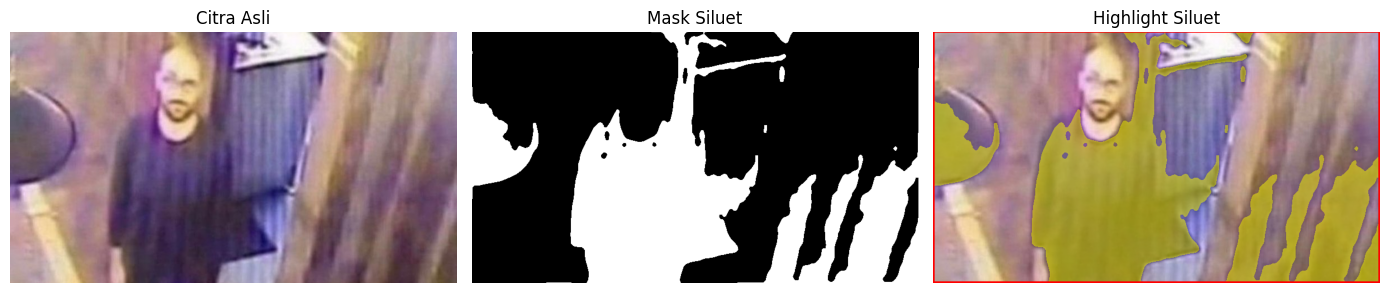

In [16]:
img     = cv2.imread('backup.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = gaussian_blur_manual(gray, sigma=1.5)
mask = threshold_inv_manual(blurred, nilai=100)
mask_clean = filter(mask, 9, mode='median')
mask_biner = threshold(mask_clean, nilai=127)

def highlight_area(img_rgb, mask, color=(255, 255, 0), alpha=0.5):
    result = img_rgb.copy().astype(np.float32)
    for c, val in enumerate(color):
        ch = result[:, :, c]
        ch[mask == 255] = ch[mask == 255] * (1 - alpha) + val * alpha
        result[:, :, c] = ch
    return np.clip(result, 0, 255).astype(np.uint8)


def find_bounding_box(mask):
    coords = np.argwhere(mask == 255) 
    if coords.size == 0:
        return None
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return x_min, y_min, x_max, y_max

def draw_rectangle_manual(img, x_min, y_min, x_max, y_max,
                           color=(255, 0, 0), thickness=3):
    result = img.copy()
    h, w = result.shape[:2]
    x_min = max(0, x_min);  y_min = max(0, y_min)
    x_max = min(w-1, x_max); y_max = min(h-1, y_max)
    for t in range(thickness):
        if y_min+t < h: result[y_min+t, x_min:x_max+1] = color  # atas
        if y_max-t >= 0: result[y_max-t, x_min:x_max+1] = color  # bawah
        if x_min+t < w: result[y_min:y_max+1, x_min+t] = color  # kiri
        if x_max-t >= 0: result[y_min:y_max+1, x_max-t] = color  # kanan
    return result

highlighted = highlight_area(img_rgb, mask_biner, color=(255, 255, 0), alpha=0.5)

bbox = find_bounding_box(mask_biner)
if bbox is not None:
    x_min, y_min, x_max, y_max = bbox
    highlighted = draw_rectangle_manual(highlighted,
                                        x_min, y_min, x_max, y_max,
                                        color=(255, 0, 0), thickness=3)


# 8. Visualisasi
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
ax1.imshow(img_rgb);              ax1.set_title("Citra Asli")
ax2.imshow(mask_biner, cmap='gray'); ax2.set_title("Mask Siluet")
ax3.imshow(highlighted);          ax3.set_title("Highlight Siluet")

ax1.axis('off'); ax2.axis('off'); ax3.axis('off')
plt.tight_layout()
plt.show()

Cell ini menangani citra kedua yaitu david.jpg. Dua fungsi silhouette_mask(image) adalah Fungsi untuk memisahkan foreground dari background berdasarkan warna. Pemisahan dilakukan dengan mengecek setiap piksel pada kanal RGB: piksel dinyatakan sebagai background toska jika nilai hijau (G) dan biru (B) masing-masing lebih besar dari merah (R) dengan selisih minimal 50, dan selisih antara G dan B tidak lebih dari 40. Piksel yang memenuhi kondisi ini diberi nilai 0 (background), sedangkan yang tidak memenuhi diberi nilai 255 (foreground). Setelah mask terbentuk, dilakukan filter median berukuran 5×5 untuk membersihkan titik-titik kecil yang tidak merata.
background_removal(image, mask) adalah Fungsi untuk menghilangkan background berdasarkan mask yang sudah dibuat. Untuk setiap piksel, jika nilai mask-nya di atas 127 maka piksel asli dipertahankan, sedangkan jika tidak maka piksel tersebut diganti dengan warna putih [255, 255, 255].
Setelah kedua fungsi didefinisikan, citra david.jpg dibaca dan dikonversi ke RGB maupun grayscale. Deteksi tepi dilakukan pada versi grayscale menggunakan operator Prewitt. Kemudian mask siluet dibuat, lalu background dihilangkan.

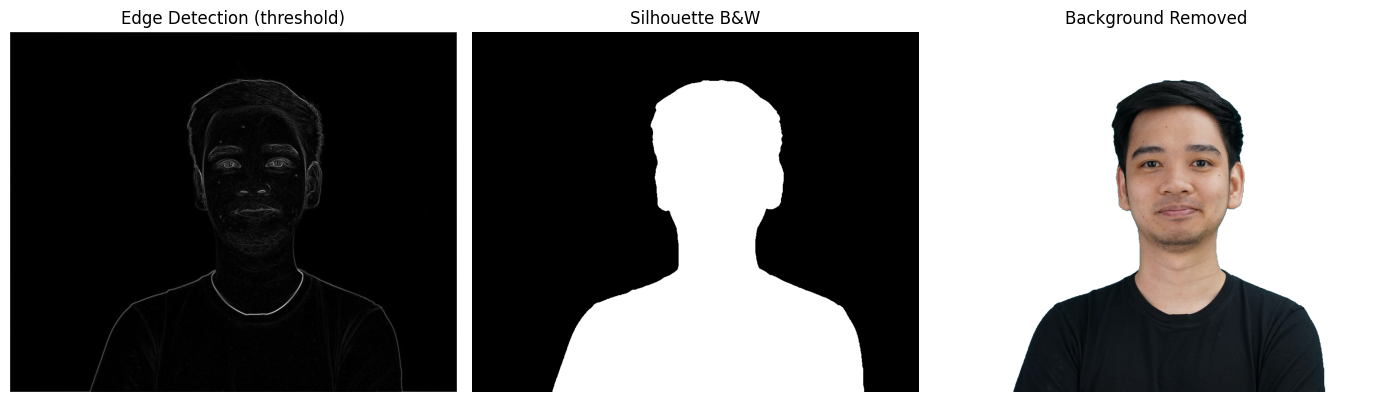

In [12]:
def silhouette_mask(image):
    B_ch = image[:, :, 0].astype(int)
    G_ch = image[:, :, 1].astype(int)
    R_ch = image[:, :, 2].astype(int)
    
    h, w = R_ch.shape
    mask = np.zeros((h, w), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            r, g, b = R_ch[y, x], G_ch[y, x], B_ch[y, x]
            is_toska = (g > r + 50) and (b > r + 50) and (abs(g - b) < 40)
            mask[y, x] = 0 if is_toska else 255

    mask_clean = filter(mask, 5, mode='median')
    return mask_clean

def background_removal(image, mask):
    hasil = np.zeros_like(image, dtype=np.uint8)
    h, w = mask.shape
    for y in range(h):
        for x in range(w):
            if mask[y, x] > 127:
                hasil[y, x] = image[y, x]
            else:
                hasil[y, x] = [255, 255, 255]
    return hasil

david = cv2.imread('david.jpg')
david_rgb = cv2.cvtColor(david, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)

david_edge = prewitt(david_gray)
silhouette = silhouette_mask(david)
david_remove = background_removal(david, silhouette)
david_remove_rgb = cv2.cvtColor(david_remove, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))
ax1.imshow(david_edge, cmap='gray'); ax1.set_title('Edge Detection (threshold)')
ax2.imshow(silhouette, cmap='gray'); ax2.set_title('Silhouette B&W')
ax3.imshow(david_remove_rgb); ax3.set_title('Background Removed')

ax1.axis('off'); ax2.axis('off'); ax3.axis('off')
plt.tight_layout()
plt.show()